In [1]:
%pip install scikit-learn pandas --user

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install numpy


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: numpy in c:\python310\lib\site-packages (2.1.1)



You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [10]:

ds= pd.read_csv("full.csv")
col_names = ds.columns
col_names

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'WikiId', 'Name_wiki',
       'Age_wiki', 'Hometown', 'Boarded', 'Destination', 'Lifeboat', 'Body',
       'Class'],
      dtype='object')

In [11]:
ds.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,WikiId,Name_wiki,Age_wiki,Hometown,Boarded,Destination,Lifeboat,Body,Class
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,S,691.0,"Braund, Mr. Owen Harris",22.0,"Bridgerule, Devon, England",Southampton,"Qu'Appelle Valley, Saskatchewan, Canada",NaN,NaN,3.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,C,90.0,"Cumings, Mrs. Florence Briggs (née Thayer)",35.0,"New York, New York, US",Cherbourg,"New York, New York, US",4,NaN,1.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,S,865.0,"Heikkinen, Miss Laina",26.0,"Jyväskylä, Finland",Southampton,New York City,14?,NaN,3.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,S,127.0,"Futrelle, Mrs. Lily May (née Peel)",35.0,"Scituate, Massachusetts, US",Southampton,"Scituate, Massachusetts, US",D,NaN,1.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,S,627.0,"Allen, Mr. William Henry",35.0,"Birmingham, West Midlands, England",Southampton,New York City,NaN,NaN,3.0


In [12]:
print(ds.info())
print(ds.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  WikiId       1304 non-null   float64
 13  Name_wiki    1304 non-null   object 
 14  Age_wiki     1302 non-null   float64
 15  Hometown     1304 non-null   object 
 16  Boarded      1304 non-null   object 
 17  Destination  1304 non-null   object 
 18  Lifeboat     502 non-null    object 
 19  Body  

In [13]:
ds.head()  
ds.tail()
ds.shape  
ds.info() 
ds.describe() 
ds.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  WikiId       1304 non-null   float64
 13  Name_wiki    1304 non-null   object 
 14  Age_wiki     1302 non-null   float64
 15  Hometown     1304 non-null   object 
 16  Boarded      1304 non-null   object 
 17  Destination  1304 non-null   object 
 18  Lifeboat     502 non-null    object 
 19  Body  

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
WikiId            5
Name_wiki         5
Age_wiki          7
Hometown          5
Boarded           5
Destination       5
Lifeboat        807
Body           1179
Class             5
dtype: int64

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
col_names = pd.DataFrame(ds)
ds = ds.fillna(0)
X_ds = ds[['Pclass', 'Age', 'SibSp','Parch', 'Fare', 'WikiId', 'Age_wiki', 'Boarded', 'Lifeboat', 'Body', 'Class']]
y_ds = ds["Survived"]
fash_ds = pd.concat([X_ds, y_ds], axis=1)
fash_ds

,Pclass,Age,SibSp,Parch,Fare,WikiId,Age_wiki,Boarded,Lifeboat,Body,Class,Survived
0,3,22.0,1,0,7.2500,691.0,22.0,Southampton,0,0,3.0,0.0
1,1,38.0,1,0,71.2833,90.0,35.0,Cherbourg,4,0,1.0,1.0
2,3,26.0,0,0,7.9250,865.0,26.0,Southampton,14?,0,3.0,1.0
3,1,35.0,1,0,53.1000,127.0,35.0,Southampton,D,0,1.0,1.0
4,3,35.0,0,0,8.0500,627.0,35.0,Southampton,0,0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0.0,0,0,8.0500,1227.0,23.0,Southampton,0,0,3.0,0.0
1305,1,39.0,0,0,108.9000,229.0,39.0,Cherbourg,8,0,1.0,0.0
1306,3,38.5,0,0,7.2500,1169.0,43.0,Southampton,0,32MB,3.0,0.0
1307,3,0.0,0,0,8.0500,1289.0,34.0,Southampton,0,0,3.0,0.0


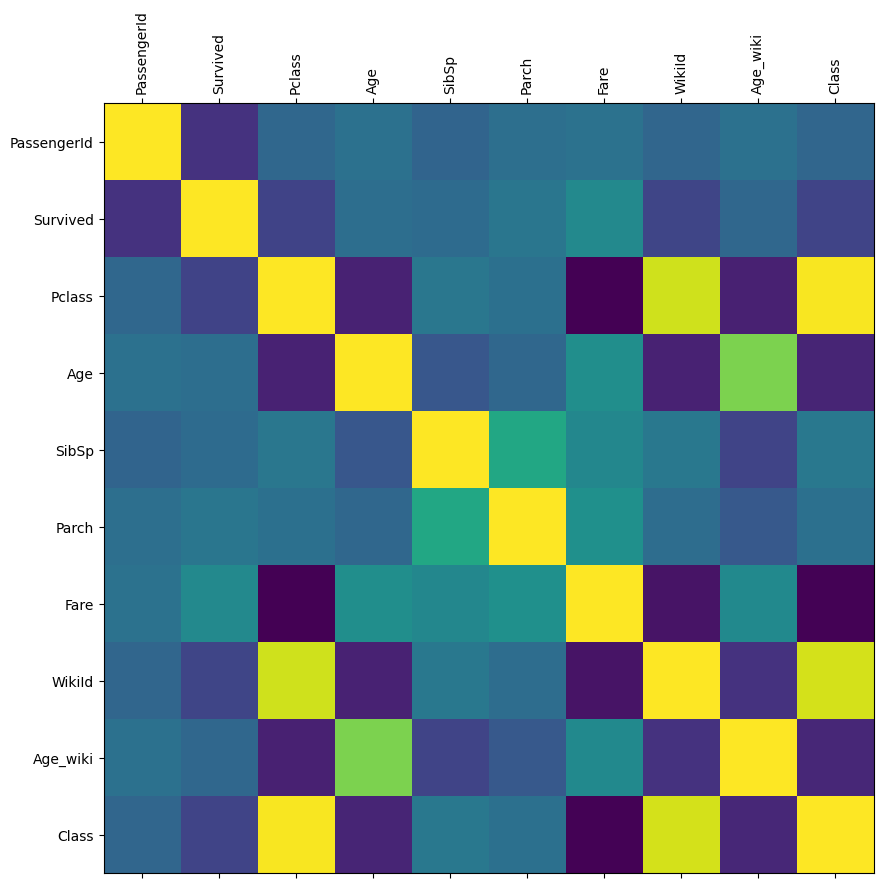

In [15]:
numerical_columns = ds.select_dtypes(include=[np.number])
tit = numerical_columns.corr()
fig, ax = plt.subplots(figsize=(10, 10))
ax.matshow(tit)
plt.xticks(range(len(tit.columns)), tit.columns)
plt.xticks(rotation=90)
plt.yticks(range(len(tit.columns)), tit.columns)

plt.show()

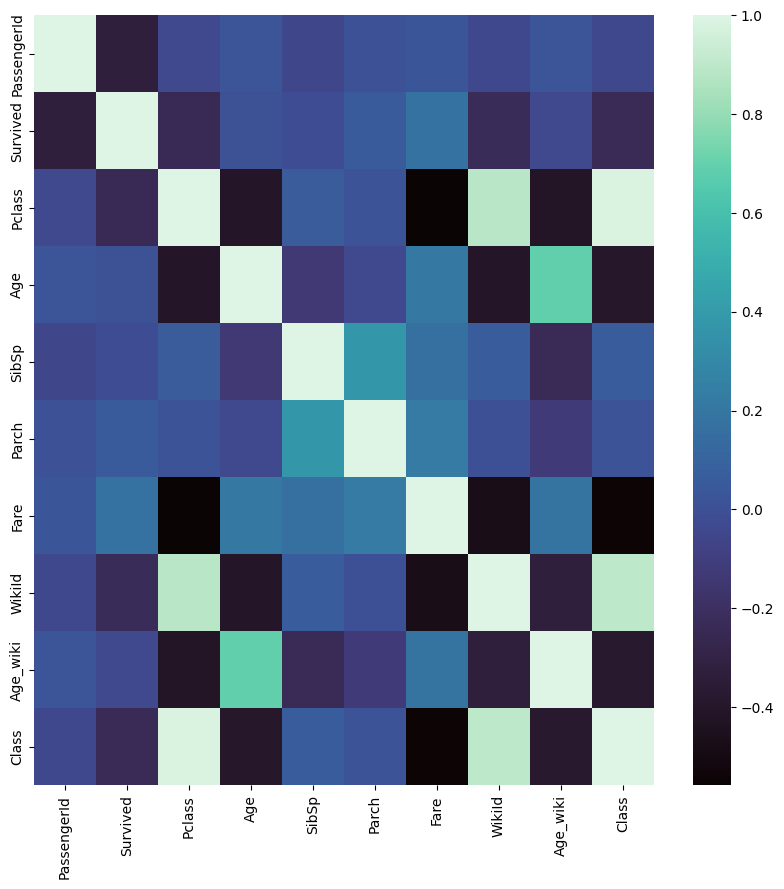

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(tit, ax=ax, cmap="mako")
plt.show()

In [17]:
ds["Survived"].value_counts()

Survived
0.0    967
1.0    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='Count'>

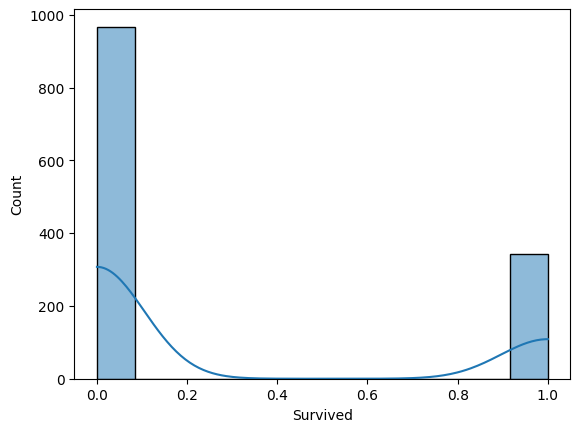

In [18]:
sns.histplot(ds["Survived"], kde=True)

<Axes: xlabel='Age', ylabel='Count'>

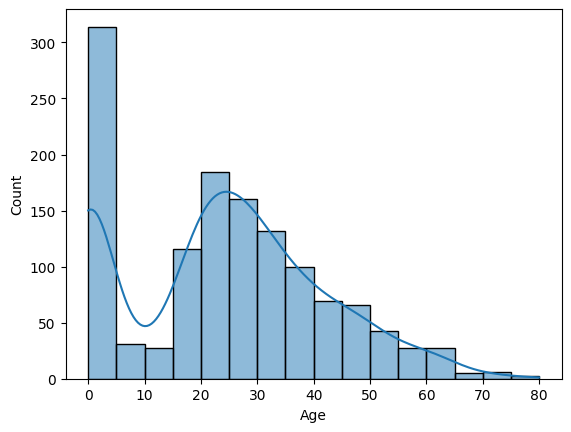

In [19]:
sns.histplot(ds["Age"], kde=True)

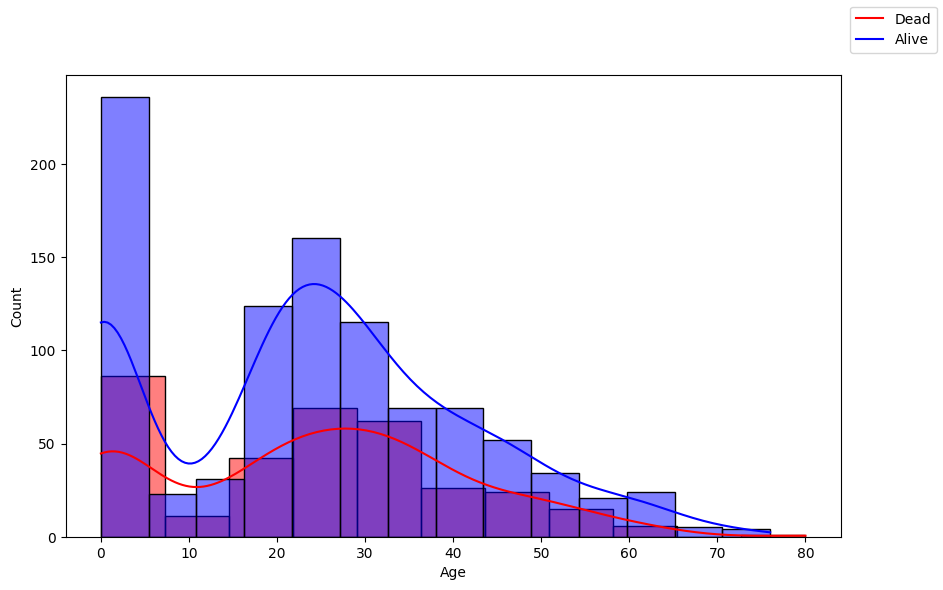

In [20]:
ds_true = ds[ds["Survived"] == 1]
ds_false = ds[ds["Survived"] == 0]

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(ds_true["Age"], kde=True, color="red", ax=ax)
sns.histplot(ds_false["Age"], kde=True, color="blue", ax=ax)

fig.legend(labels=["Dead", "Alive"])

TypeError: 'value' must be an instance of str or bytes, not a int

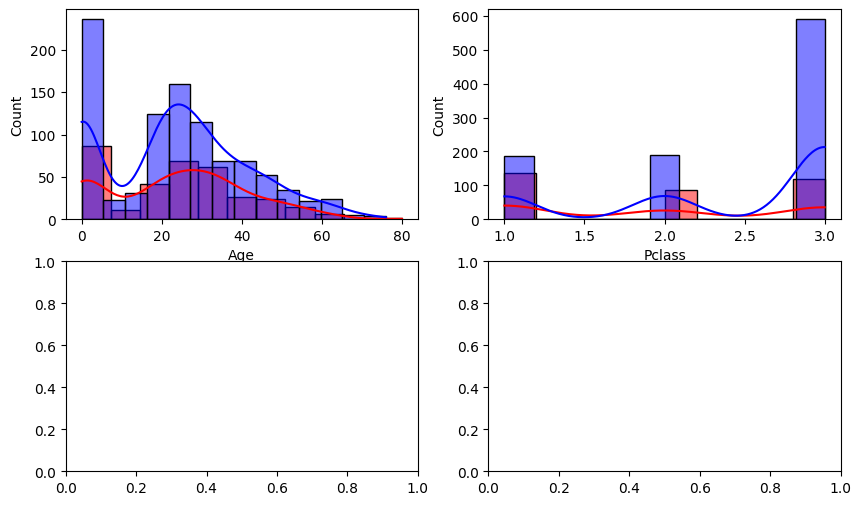

In [21]:
ds_true = ds[ds["Survived"] == 1]
ds_false = ds[ds["Survived"] == 0]

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

sns.histplot(ds_true["Age"], kde=True, color="red", ax=axs[0, 0])
sns.histplot(ds_false["Age"], kde=True, color="blue", ax=axs[0, 0])

sns.histplot(ds_true["Pclass"], kde=True, color="red", ax=axs[0, 1])
sns.histplot(ds_false["Pclass"], kde=True, color="blue", ax=axs[0, 1])

sns.histplot(ds_true["Lifeboat"], kde=True, color="red", ax=axs[1, 0])
sns.histplot(ds_false["Lifeboat"], kde=True, color="blue", ax=axs[1, 0])

sns.histplot(ds_true["Class"], kde=True, color="red", ax=axs[1, 1])
sns.histplot(ds_false["Class"], kde=True, color="blue", ax=axs[1, 1])

fig.legend(labels=["Died", "Alive"])

fig.tight_layout()

<Axes: xlabel='Sex', ylabel='Survived'>

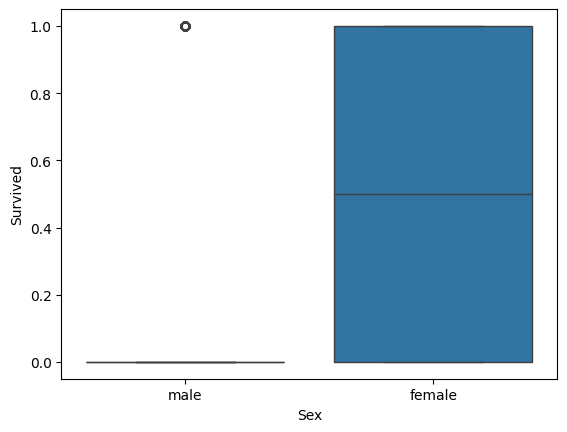

In [22]:
sns.boxplot(x='Sex', y='Survived', data=ds)

<Axes: >

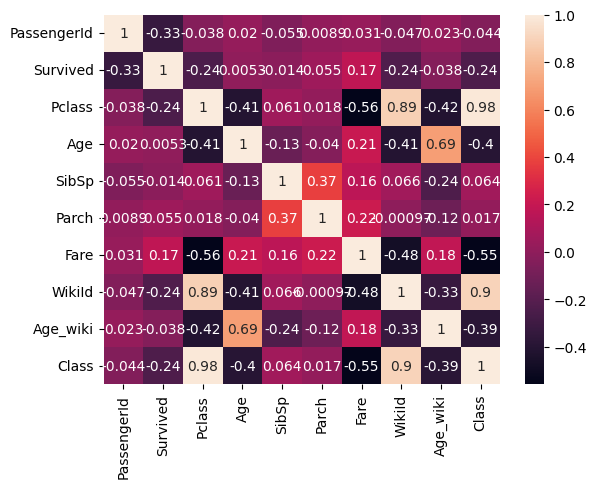

In [23]:
numerical_columns = ds.select_dtypes(include=[np.number])
tit = numerical_columns.corr()
corr_matrix = tit
sns.heatmap(corr_matrix, annot=True)

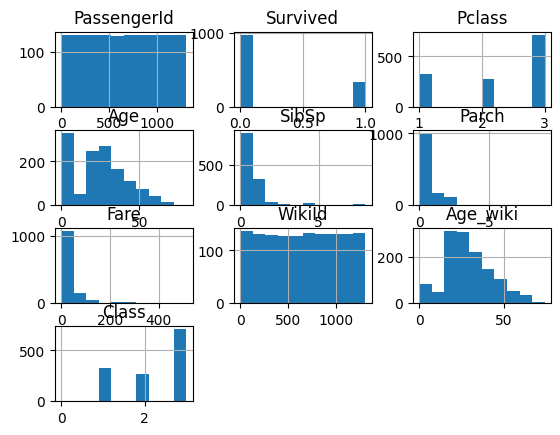

In [24]:
ds.hist()
plt.show()

In [25]:
# sns.pairplot(ds, hue="Survived")

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000002DB0686D5A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [37]:
X_ds = X_ds.select_dtypes(include=[np.number])

In [38]:
seed=42
X_train, X_test, y_train, y_test = train_test_split(X_ds, y_ds, test_size=0.2, random_state=seed)

In [30]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
numerical_columns = X_train.select_dtypes(include=[np.number])
log_model.fit(numerical_columns, y_train)

c:\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
y_pred = log_model.predict(X_test.select_dtypes(include=[np.number]))

Accuracy: 0.7251908396946565


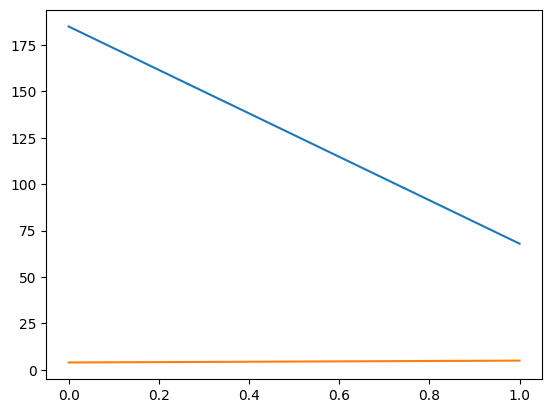

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
conf_matrix = confusion_matrix(y_test, y_pred)
# fig, ax = plt.subplots(figsize=(10, 6))
# sns.heatmap(ds, annot=True, ax=ax)
# _ = plt.xlabel("Predicted")
# _ = plt.ylabel("Actual")

plt.plot(conf_matrix)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()), 
    ("logistic", LogisticRegression())
])

pipe.fit(X_train, y_train.values.ravel())

y_pred_scale = pipe.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_scale)
cm = confusion_matrix(y_test, y_pred_scale)

print("Accuracy:", accuracy)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cm, annot=True, ax=ax)
_ = plt.xlabel("Predicted")
_ = plt.ylabel("Actual")

In [ ]:
print("Coefficients:", log_model.coef_)
print("Intercept:", log_model.intercept_)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(X_ds.columns, log_model.coef_[0])

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

feature_importances = pd.DataFrame(
    {"column": X_ds.columns, "coef": np.abs(log_model.coef_[0])}
).sort_values(by="coef", ascending=True)

ax.barh(feature_importances["column"], feature_importances["coef"])

In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

feature_importances = pd.DataFrame(
    {"column": X_ds.columns, "coef": np.abs(pipe.named_steps["logistic"].coef_[0])}
).sort_values(by="coef", ascending=True)

ax.barh(feature_importances["column"], feature_importances["coef"])

              precision    recall  f1-score   support

         0.0       0.77      0.80      0.78       189
         1.0       0.42      0.38      0.40        73

    accuracy                           0.68       262
   macro avg       0.60      0.59      0.59       262
weighted avg       0.67      0.68      0.68       262



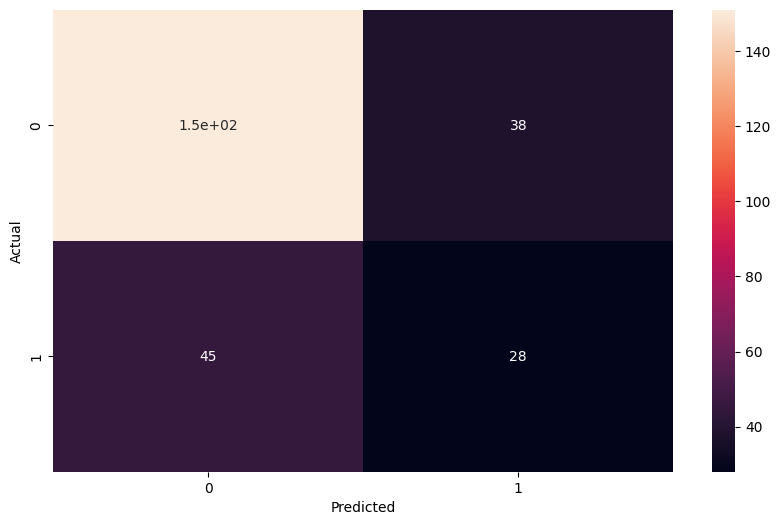

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# X_ds = pd.DataFrame(ds.data, columns=ds.feature_names)
# y_ds = pd.DataFrame(ds.target, columns=["survived"])
full_ds = pd.concat([X_ds, y_ds], axis=1)
seed = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_ds, y_ds, test_size=0.2, random_state=seed) 
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cm, annot=True, ax=ax)
_ = plt.xlabel("Predicted")
_ = plt.ylabel("Actual")

print(classification_report(y_test, y_pred))

In [40]:
accuracy

0.683206106870229

In [20]:
%pip install pydotplus

Using legacy 'setup.py install' for pydotplus, since package 'wheel' is not installed.
    Running setup.py install for pydotplus: started
    Running setup.py install for pydotplus: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Python310\python.exe -m pip install --upgrade pip' command.


In [41]:
import pydotplus
from six import StringIO
from IPython.display import Image, display
from sklearn.tree import export_graphviz


def dibujar_arbol(
    clf, c_name=ds.target_names, f_name=ds.feature_names
):

    dot_data = StringIO()

    export_graphviz(
        clf,
        out_file=dot_data,
        filled=True,
        class_names=c_name,
        feature_names=f_name,
        special_characters=True,
    )

    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    display(Image(graph.create_png()))


arbol = DecisionTreeClassifier(max_depth=3)
arbol.fit(ds["data"], ds["target"])

dibujar_arbol(arbol)

AttributeError: 'DataFrame' object has no attribute 'target_names'

In [ ]:
importances = dt_model.feature_importances_[::-1]
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.barh(range(X_train.shape[1]), importances[indices], align="center")
plt.yticks(range(X_train.shape[1]), X_train.columns[indices])
plt.xlabel("Relative Importance")
plt.show()

In [ ]:
arbol = DecisionTreeClassifier(max_depth=30)
arbol.fit(ds["data"], ds["target"])

dibujar_arbol(arbol)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
X = ds.select_dtypes(include=[numerical_columns])  
y = ds['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred_arbol = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Precisión:", accuracy) 

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names= ds.feature_names, class_names= ds.target_names)
plt.show()

In [ ]:
y_pred_arbol = clf.predict(X_test)
y_pred_logreg = logreg.predict(X_test)
accuracy_arbol = accuracy_score(y_test, y_pred_arbol)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
conf_matrix_arbol = confusion_matrix(y_test, y_pred_arbol)
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)

In [1]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
categorical_cols = ds.select_dtypes(include=['object']).columns
numerical_cols = ds.select_dtypes(include=['number']).columns
encoder = OneHotEncoder()
encoded_categorical = encoder.fit_transform(ds[categorical_cols])
scaler = StandardScaler()
scaled_numerical = scaler.fit_transform(ds[numerical_cols])
ds_encoded = np.concatenate([encoded_categorical.toarray(), scaled_numerical], axis=1)

NameError: name 'ds' is not defined

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(df_encoded, y, test_size=0.2, random_state=42)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
param_grid = {'max_depth': [3, 5, 7], 'min_samples_split': [2, 5, 10]}
tree_model = DecisionTreeClassifier()
grid_search = GridSearchCV(tree_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_tree_model = grid_search.best_estimator_


In [ ]:
from sklearn.metrics import precision_score, roc_auc_score, confusion_matrix
y_pred_log = log_model.predict(X_test)
y_pred_tree = best_tree_model.predict(X_test)
print("Regresión Logística:")
print("Precisión:", precision_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_pred_log))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_log))
print("\nÁrbol de Decisión:")
print("Precisión:", precision_score(y_test, y_pred_tree))
print("ROC AUC:", roc_auc_score(y_test, y_pred_tree))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred_tree))
importances = best_tree_model.feature_importances_